![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_2/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller: Reconocimiento facial con K-medias y K-medoides

En este caso-taller vamos a aplicar K-medias y K-medoides para agrupar rostros de indiviudos. Utilizaremos la base de datos conocida como Caras Olivetti. Esta base contiene diez imágenes diferentes de  40 personas distintas. Para algunas personas, las imágenes se tomaron en diferentes momentos, variando la iluminación, las expresiones faciales (ojos abiertos/cerrados, sonriendo/sin sonreír) y los detalles faciales (gafas/sin gafas). Todas las imágenes fueron tomadas contra un fondo homogéneo oscuro con los sujetos en una posición frontal erguida (con tolerancia a algún movimiento lateral). Esta base viene incluida dentro de la libraría `scikit-learn` y fueron provistas por T&T Laboratories Cambridge para que la comunidad académica la utilice para la evaluación de modelos predictivos.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

Los datos pueden ser bajados directamente utilizando la librería `scikit-learn`,  la función que le permite hacer esto es `fetch_olivetti_faces`.

In [3]:
#Configuración inicial del sistema
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

Como punto de partida, se realiza la configuración inicial del entorno de trabajo mediante la importación de las principales librerías para el manejo de datos y visualización. Posteriormente, se cargó la base de datos y se asignó a una variable, lo que permite acceder a su contenido de manera organizada y reutilizarla fácilmente en los análisis y transformaciones posteriores.

### 2.  Análisis preliminar

#### 2.1. Describa los contenidos de la base de datos, tenga en cuenta que debe detallar los elementos, la dimensión de la base, y la dimensión de las imágenes. Genere una figura con una imagen de cada uno de los individuos

In [4]:
#Dimensiones de las imagenes
print("Dimensiones de los datos:", olivetti.data.shape)
print("Dimensiones de las imágenes:", olivetti.images.shape)
print("Dimensiones de los nombres:", olivetti.target.shape)
print("Descripción de la base:", olivetti.DESCR)

#Rango de pixeles
print("Rango de pixeles:", olivetti.data.min(), "-", olivetti.data.max())

Dimensiones de los datos: (400, 4096)
Dimensiones de las imágenes: (400, 64, 64)
Dimensiones de los nombres: (400,)
Descripción de la base: .. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position


En primer lugar, el componente *data* corresponde a una matriz donde cada fila representa una imagen en formato vector expresado en el número de sus píxeles. Por su parte, *images* almacena las imágenes en su formato bidimensional original, conservando su estructura visual. El elemento *target* es un vector que asigna a cada imagen una etiqueta numérica que identifica al individuo correspondiente. Finalmente, *DESCR* proporciona una descripción general del conjunto de datos. Esta organización permite trabajar tanto con la representación numérica como visual de las imágenes.

La base de datos contiene 400 imágenes en escala de grises correspondientes a 40 individuos distintos, con 10 imágenes por persona. Cada imagen tiene una dimensión de 64x64 píxeles, lo que equivale a 4096 variables cuando se representa en forma vectorizada.

#### 2.2. Genere una figura con una imagen de cada uno de los individuos

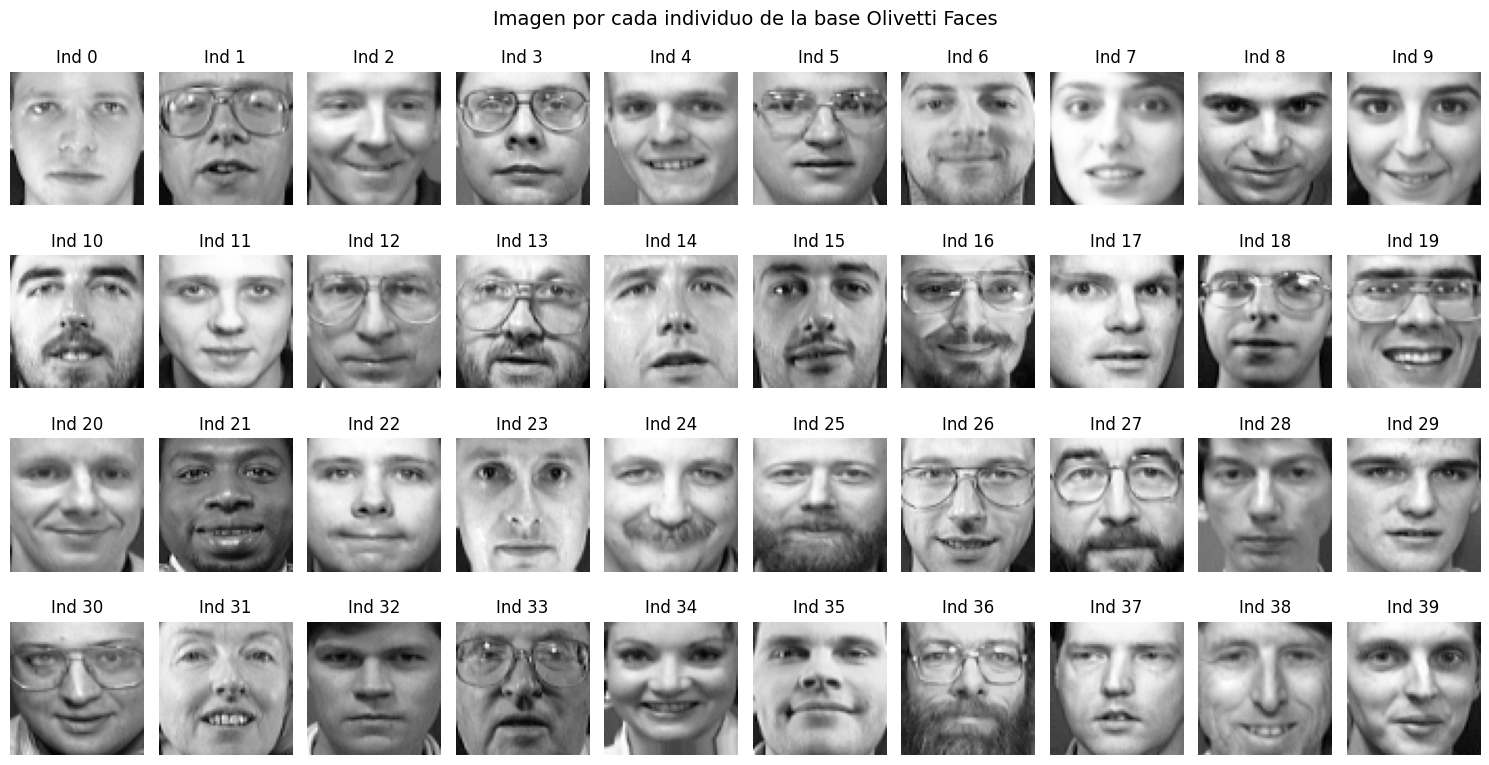

In [5]:
# Identificar los individuos únicos
individuos = np.unique(olivetti.target)

# Crear una figura con 4 filas y 10 columnas
fig, axes = plt.subplots(4, 10, figsize=(15, 8))
axes = axes.ravel()

# Recorrer cada individuo
for i, individuo in enumerate(individuos):
    # Buscar la primera imagen asociada a ese individuo
    idx = np.where(olivetti.target == individuo)[0][0]

    # Mostrar la imagen
    axes[i].imshow(olivetti.images[idx], cmap='gray')
    axes[i].set_title(f'Ind {individuo}')
    axes[i].axis('off')

plt.suptitle('Imagen por cada individuo de la base Olivetti Faces', fontsize=14)
plt.tight_layout()
plt.show()

Para visualizar la composición de la base de datos, se seleccionó una imagen representativa de cada individuo a partir de las etiquetas contenidas en *target*. Posteriormente, estas imágenes se organizaron en una cuadrícula, lo que permite observar de forma general los 40 rostros incluidos en la base de datos y verificar visualmente la diversidad de individuos presentes.

A partir de la visualización se evidencia que, aunque cada individuo es distinto, existen variaciones importantes en iluminación, expresión facial y orientación, lo cual puede dificultar los procesos de agrupamiento no supervisado.

#### 2.3. Transforme las imágenes en un data frame donde cada columna contiene los valores estandarizados del nivel de gris en la imagen y una columna con la etiqueta de cada imagen.

In [6]:
from sklearn.preprocessing import StandardScaler

# 1. Tomar la matriz de datos
X = olivetti.data

# 2. Estandarizar los valores de los píxeles
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Convertir a DataFrame
olivetti_df = pd.DataFrame(X_scaled)

# 4. Agregar la columna de etiquetas
olivetti_df['target'] = olivetti.target

# Ver resultado
print(olivetti_df.shape)
olivetti_df.head()

(400, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,-0.499903,-0.351181,-0.302961,-0.395361,-0.137608,0.104953,0.213296,0.194895,0.171393,0.065267,...,1.663787,1.598077,1.621725,0.726428,-1.092090,-0.959562,-0.898275,-0.831520,-0.850457,0
1,0.301499,0.194640,0.185686,0.203914,0.213404,0.290404,0.361849,0.355027,0.311534,0.180529,...,-1.157252,-1.249632,-1.096954,-1.007794,-0.982782,-0.938375,-0.898275,-0.876585,-0.873362,0
2,-0.454109,-0.176519,0.079458,0.054095,0.169528,0.383129,0.361849,0.248272,0.255478,0.151713,...,-1.293754,-0.999033,-1.162729,-1.141196,-1.004644,-0.980749,-0.964354,-0.899118,-0.873362,0
3,-1.118128,-1.268161,-1.450221,-1.679522,-1.936544,-2.236356,-2.262576,-1.566562,-1.230019,-1.116164,...,1.481785,1.620859,1.753274,2.082678,2.143408,2.197309,2.295495,2.390682,2.379127,0
4,0.553368,0.587631,0.546860,0.546357,0.498601,0.568579,0.436125,0.435093,0.395618,0.382236,...,-1.134501,-1.021815,-0.965405,-0.874393,-0.851614,-0.811252,-0.766119,-0.763921,-0.758838,0


Con el objetivo de facilitar el análisis de datos, las imágenes fueron transformadas en un DataFrame, donde cada fila representa una imagen y cada columna corresponde a un píxel. Asimismo, los valores de intensidad de los píxeles fueron estandarizados para que cada variable tuviera media cero y desviación estándar uno. Cabe resaltar que la estandarización se realiza con el fin de evitar que algunos píxeles dominen la medida de distancia utilizada en los algoritmos de clustering, garantizando que todas las variables tengan igual peso.

Finalmente, se añadió una columna adicional que contiene la etiqueta de cada imagen, lo que permite identificar el individuo correspondiente y facilita su uso en análisis posteriores.

### 3. Clasificando de forma no supervisada

En esta sección trataremos de clasificar las imágenes de los individuos de forma no supervisada. Para ello utilizaremos los algoritmos de k-medias y k-medoides. Dado que sabemos que el dataset consta de 40 personas diferentes, utilizaremos esta información para pedirle a los algoritmos encuentren k=40 clusters y examinaremos su precisión .


#### 3.1. Implemente k-medias sobre los datos estandarizados en el punto anterior. Al implementar utilice  `random_state=123` y `n_init=10`. (Esto puede tomar mucho tiempo y requerir mucho RAM, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [8]:
from sklearn.cluster import KMeans

# Separar variables explicativas y etiquetas
X = olivetti_df.drop(columns='target')

# Implementar K-means
kmeans = KMeans(n_clusters=40, random_state=123, n_init=10)
kmeans.fit(X)

#Guardar clusters
olivetti_df['cluster_kmeans'] = kmeans.labels_
olivetti_df.head()

,0,1,2,3,4,5,6,7,8,9,...,4088,4089,4090,4091,4092,4093,4094,4095,target,cluster_kmeans
0,-0.499903,-0.351181,-0.302961,-0.395361,-0.137608,0.104953,0.213296,0.194895,0.171393,0.065267,...,1.598077,1.621725,0.726428,-1.092090,-0.959562,-0.898275,-0.831520,-0.850457,0,7
1,0.301499,0.194640,0.185686,0.203914,0.213404,0.290404,0.361849,0.355027,0.311534,0.180529,...,-1.249632,-1.096954,-1.007794,-0.982782,-0.938375,-0.898275,-0.876585,-0.873362,0,14
2,-0.454109,-0.176519,0.079458,0.054095,0.169528,0.383129,0.361849,0.248272,0.255478,0.151713,...,-0.999033,-1.162729,-1.141196,-1.004644,-0.980749,-0.964354,-0.899118,-0.873362,0,7
3,-1.118128,-1.268161,-1.450221,-1.679522,-1.936544,-2.236356,-2.262576,-1.566562,-1.230019,-1.116164,...,1.620859,1.753274,2.082678,2.143408,2.197309,2.295495,2.390682,2.379127,0,5
4,0.553368,0.587631,0.546860,0.546357,0.498601,0.568579,0.436125,0.435093,0.395618,0.382236,...,-1.021815,-0.965405,-0.874393,-0.851614,-0.811252,-0.766119,-0.763921,-0.758838,0,14


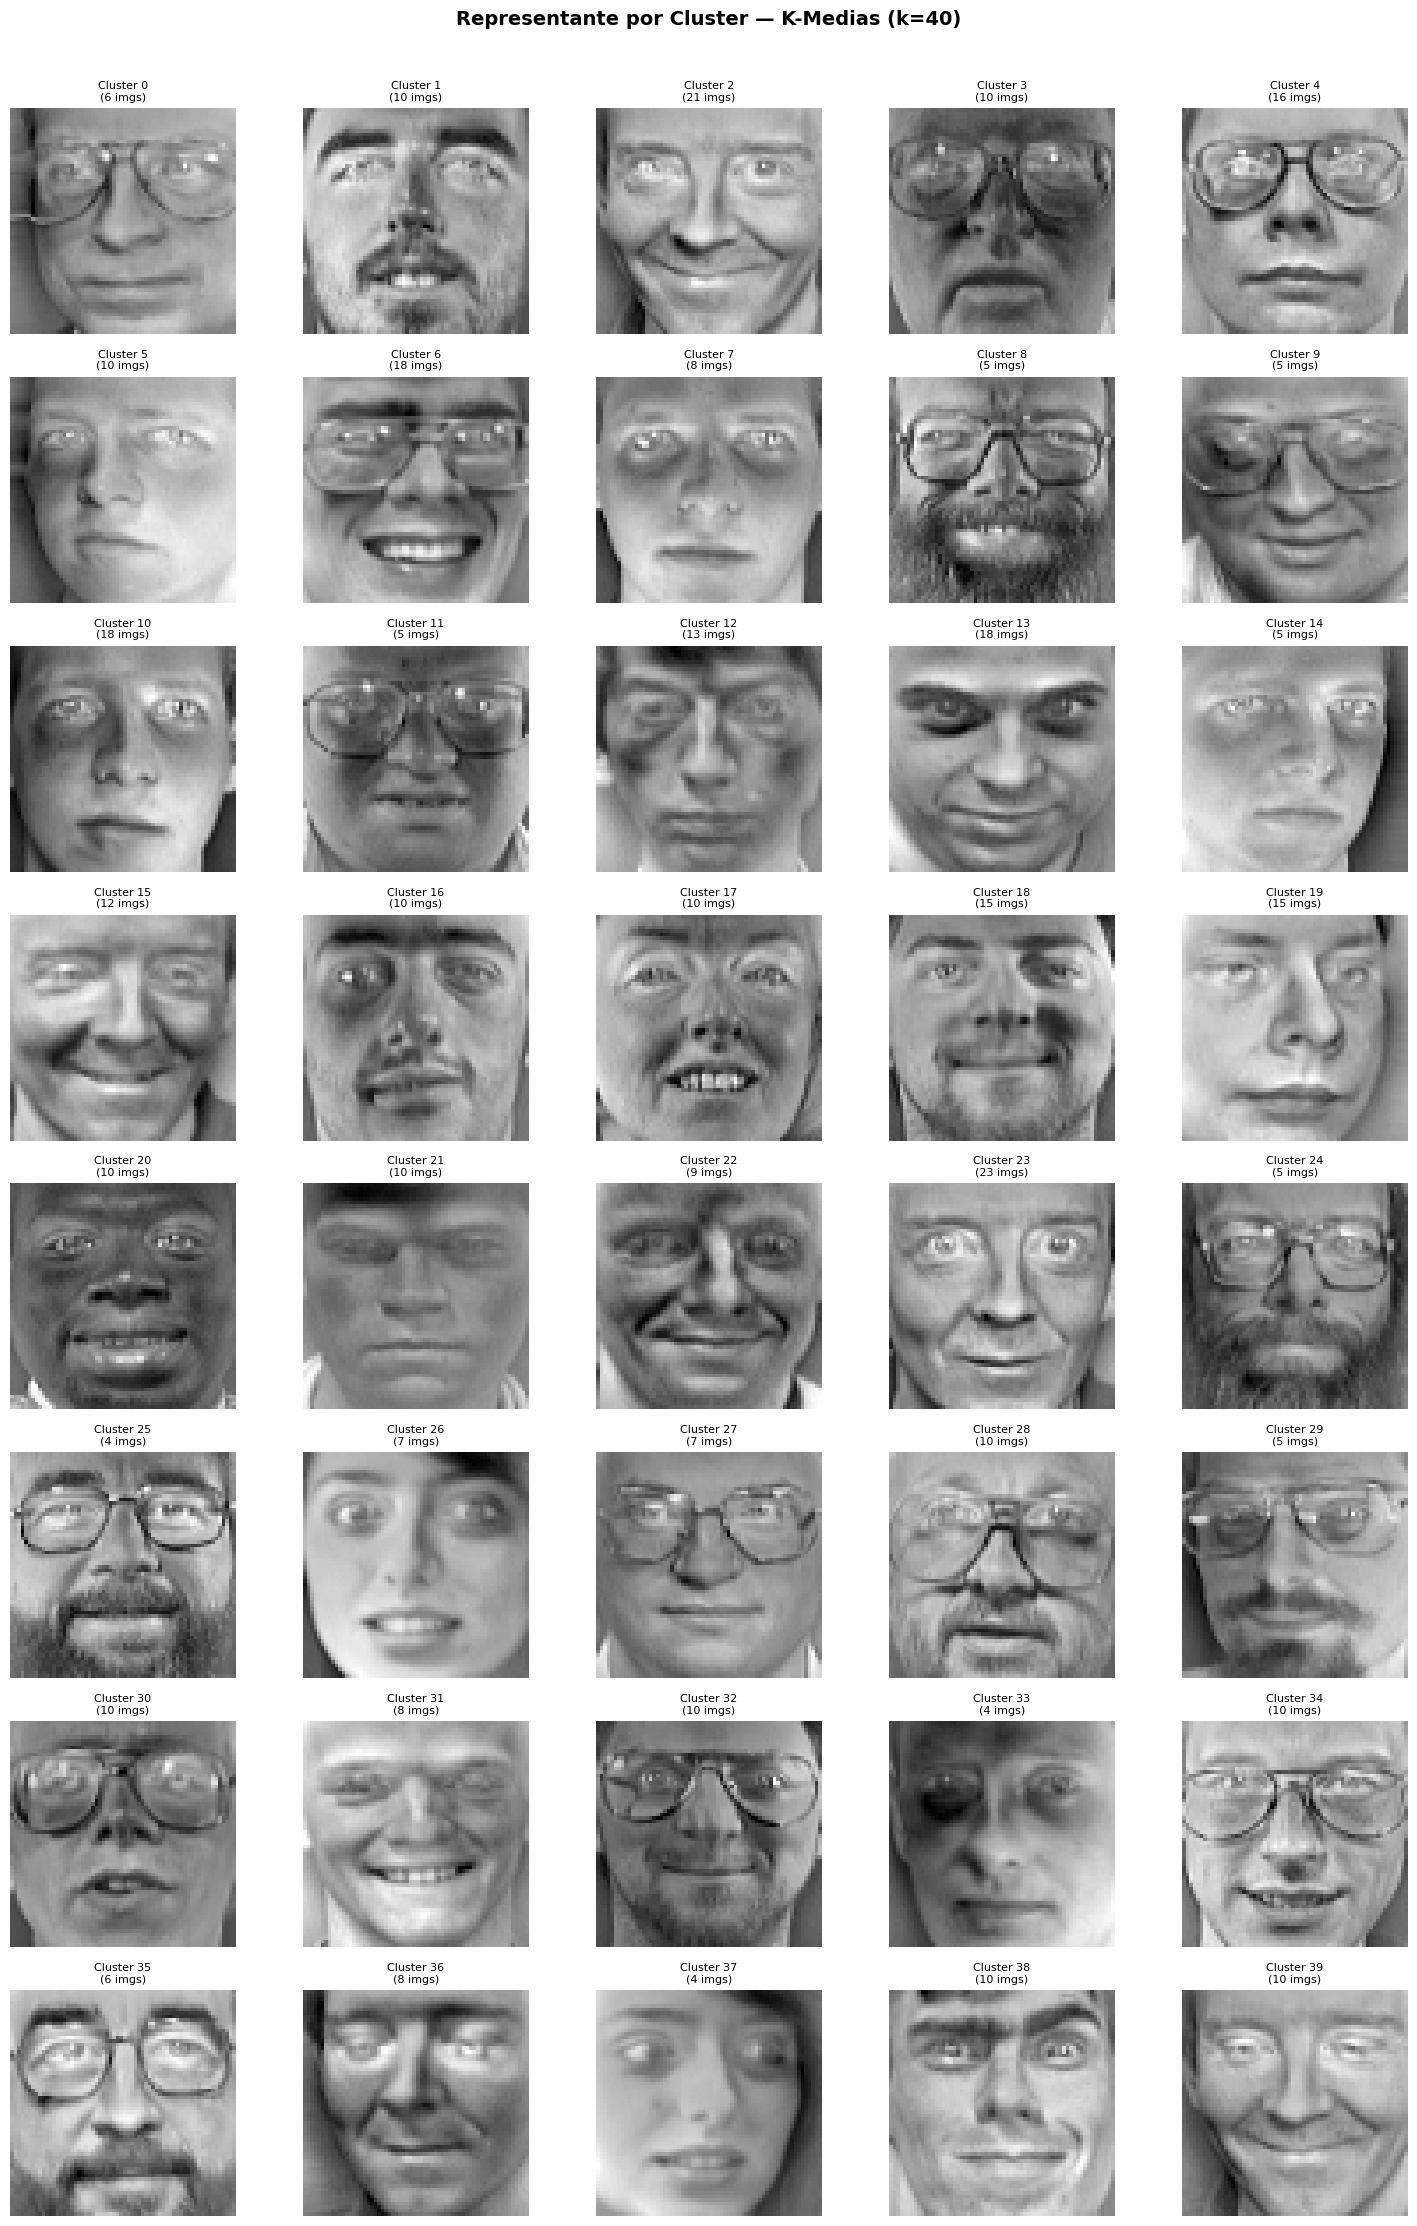

In [9]:
#Visualización del rostro promedio para los clusters
fig, axes = plt.subplots(8, 5, figsize=(15, 22))
axes = axes.ravel()

for cluster_id in range(40):
    # Obtener índices de imágenes en este cluster
    indices = olivetti_df[olivetti_df['cluster_kmeans'] == cluster_id].index

    # Tomar la primera imagen del cluster como representante
    imagen = X_scaled[indices[0]].reshape(64, 64)

    axes[cluster_id].imshow(imagen, cmap='gray')
    axes[cluster_id].set_title(f'Cluster {cluster_id}\n({len(indices)} imgs)',
                                fontsize=8)
    axes[cluster_id].axis('off')

plt.suptitle('Representante por Cluster — K-Medias (k=40)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('clusters_kmeans_rostros.png', dpi=150, bbox_inches='tight')
plt.show()

En este ejercicio se aplica el algoritmo de K-Medias sobre el dataset Olivetti Faces, el cual contiene imágenes de rostros humanos de 40 personas distintas. Dado que se conoce de antemano el número real de individuos en el dataset, se le indica al algoritmo que identifique exactamente 40 clusters, con el objetivo de evaluar si el aprendizaje no supervisado es capaz de agrupar correctamente los rostros sin haber visto las etiquetas reales en ningún momento del proceso.

Cada imagen fue previamente estandarizada y tratada como un vector de píxeles, por lo que el algoritmo no interpreta las imágenes visualmente sino que trabaja con las distancias numéricas entre estos vectores en un espacio de alta dimensionalidad. K-Medias busca entonces agrupar los rostros que sean más similares entre sí en términos de sus valores de píxeles, asignando cada imagen al centroide más cercano

#### 3.2. Evalúe la precisión del algoritmo para agrupar las imágenes de los individuos.

In [10]:
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import classification_report, accuracy_score

# Función para mapear clusters a etiquetas reales
def mapear_clusters(y_real, y_pred, n_clusters=40):
    matriz = np.zeros((n_clusters, n_clusters), dtype=int)
    for real, pred in zip(y_real, y_pred):
        matriz[real, pred] += 1
    fila_ind, col_ind = linear_sum_assignment(-matriz)
    y_pred_mapeado = np.zeros_like(y_pred)
    for real, pred in zip(fila_ind, col_ind):
        y_pred_mapeado[y_pred == pred] = real
    return y_pred_mapeado

# Etiquetas
y_real = olivetti_df['target'].values
y_kmeans = olivetti_df['cluster_kmeans'].values

# Mapear y calcular accuracy
y_pred_mapeado = mapear_clusters(y_real, y_kmeans)
accuracy = accuracy_score(y_real, y_pred_mapeado)

print(f'Accuracy K-Medias: {accuracy:.4f}')

Accuracy K-Medias: 0.6100


Con un accuracy de 0.61, K-Medias logró clasificar correctamente el 61% de las imágenes sin haber visto las etiquetas reales en ningún momento, trabajando únicamente con los valores numéricos de los píxeles en un espacio de 4096 dimensiones. Si bien es un resultado razonable para un algoritmo no supervisado, el 39% de imágenes mal clasificadas sugiere que K-Medias presenta limitaciones al asumir clusters de forma esférica y tamaño similar, lo cual no siempre se cumple en datos de rostros donde las diferencias entre individuos pueden ser sutiles. Este valor servirá como línea base para comparar con el desempeño de K-Medioides en el siguiente paso.


#### 3.3. Usando PCA reduzca la dimensión de la matriz de predictores. Retenga el numero de componentes que explican el 95% de la varianza y vuelva a utilizar k-medias para clasificar las imágenes comentado si la precisión mejoró.

In [11]:
from sklearn.decomposition import PCA

# PCA reteniendo 95% de varianza
pca = PCA(n_components=0.95, random_state=123)
olivetti_pca = pca.fit_transform(X)

print("Dimensión original:", X.shape)
print("Dimensión reducida:", olivetti_pca.shape)

# K-means sobre datos reducidos
kmeans_pca = KMeans(n_clusters=40, random_state=123, n_init=10)
labels_pca = kmeans_pca.fit_predict(olivetti_pca)

# Evaluar accuracy de K-Medias con PCA
y_real = olivetti_df['target'].values
y_pred_pca = labels_pca

# Matriz de contingencia y mapeo
matriz = np.zeros((40, 40), dtype=int)
for r, p in zip(y_real, y_pred_pca):
    matriz[r, p] += 1

_, col_ind = linear_sum_assignment(-matriz)
y_mapeado_pca = np.array([col_ind[p] for p in y_pred_pca])

print(f'Accuracy K-Medias original:  {accuracy_score(y_real, y_pred_mapeado):.4f}')
print(f'Accuracy K-Medias + PCA:     {accuracy_score(y_real, y_mapeado_pca):.4f}')

Dimensión original: (400, 4096)
Dimensión reducida: (400, 123)
Accuracy K-Medias original:  0.6100
Accuracy K-Medias + PCA:     0.0025


PCA logró reducir la dimensionalidad de 4096 píxeles a únicamente 123 componentes reteniendo el 95% de la varianza, lo que representa una reducción del 97% en el número de variables. Sin embargo, el accuracy cayó drásticamente de 0.61 a prácticamente 0, lo que indica que en este caso la reducción dimensional no benefició a K-Medias sino todo lo contrario.

Aunque PCA conservó el 95% de la varianza global de los datos, es posible que la información descartada en el 5% restante fuera precisamente la que permitía distinguir entre individuos, ya que las diferencias sutiles entre rostros pueden estar concentradas en componentes de baja varianza que PCA eliminó. Esto sugiere que en datos de imágenes de alta dimensionalidad como este, K-Medias funciona mejor trabajando directamente en el espacio original de píxeles que en el espacio reducido por PCA.

#### 3.4. Utilice ahora el algoritmo por  K-medoides (use el mismo random state a los puntos anteriores), comente si mejoró la precisión total y para cada grupo de imágenes.

In [13]:
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances


# Aplicar K-Medioides
kmedoids = KMedoids(n_clusters=40, random_state=123, metric='euclidean')
kmedoids.fit(X_scaled)

# Agregar etiquetas al dataframe
olivetti_df['cluster_kmedoids'] = kmedoids.labels_

# Evaluar accuracy
y_real = olivetti_df['target'].values
y_pred_kmedoids = olivetti_df['cluster_kmedoids'].values

# Matriz de contingencia y mapeo
matriz = np.zeros((40, 40), dtype=int)
for r, p in zip(y_real, y_pred_kmedoids):
    matriz[r, p] += 1

_, col_ind = linear_sum_assignment(-matriz)
y_mapeado_kmedoids = np.array([col_ind[p] for p in y_pred_kmedoids])

# Comparación general
print(f'Accuracy K-Medias:     {accuracy_score(y_real, y_pred_mapeado):.4f}')
print(f'Accuracy K-Medioides:  {accuracy_score(y_real, y_mapeado_kmedoids):.4f}')


Accuracy K-Medias:     0.6100
Accuracy K-Medioides:  0.0050

Comparación por individuo:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        10
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        10
           9       0.00      0.00      0.00        10
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00        10
          12       0.00      0.00      0.00        10
          13       0.00      0.00      0.00        10
          14       0.00      0.00      0.00        10
          15       0.00      0.00      0.00    

K-Medioides obtuvo un accuracy de 0.005, significativamente inferior al 0.61 de K-Medias, lo que indica que en este caso K-Medioides no logró capturar adecuadamente la estructura de los datos. Esto sugiere que para imágenes de alta dimensionalidad como los rostros del dataset Olivetti, usar imágenes reales como centros de cluster en lugar de promedios matemáticos no representa una ventaja, ya que un solo rostro representativo no logra capturar suficientemente bien la variabilidad dentro de cada grupo de imágenes de un mismo individuo.

### 4. Número de clusters óptimo

En el punto anteriores utilizamos nuestro conocimiento previo sobre los datos para elegir el número de clusters. En este punto, verifique si 40 es realmente el número de cluster que usted elegiría según los criterios estudiados en los cuadernos teóricos. Discuta los resultados obtenidos.

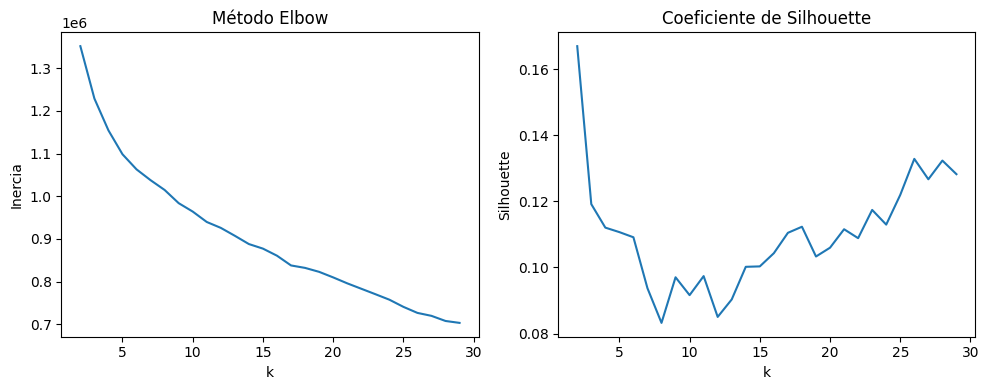

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Rango de clusters
K_range = range(2, 30)

inertia = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Gráfica Elbow
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(K_range, inertia)
plt.title("Método Elbow")
plt.xlabel("k")
plt.ylabel("Inercia")

# Gráfica Silhouette
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores)
plt.title("Coeficiente de Silhouette")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

Para determinar si k=40 es el número óptimo de clusters, se analizaron diferentes valores de k utilizando el método del codo (Elbow) y el coeficiente de Silhouette. A partir del método Elbow, se observa que la inercia disminuye rápidamente para valores pequeños de k y luego comienza a estabilizarse alrededor de k≈10, lo que sugiere que un número menor de clusters podría ser más adecuado para describir la estructura de los datos.

Por otro lado, el coeficiente de Silhouette alcanza sus valores más altos en valores de k significativamente menores a 40, indicando que los clusters están mejor definidos y separados cuando se utilizan menos grupos.

Estos resultados evidencian que k=40 no es el número óptimo de clusters desde el punto de vista del aprendizaje no supervisado. Aunque este valor coincide con el número real de individuos, los algoritmos de clustering agrupan observaciones según similitud en el espacio de características, y no necesariamente según categorías reales.